# PINN Literature Notes

# 1️⃣ Medium: Hands-on-Physics-Informed-Neural Networks

## Citation:
https://medium.com/@hridaym.211me129/hands-on-physics-informed-neural-networks-2e9bca75ab59

## Example: Burger's Equation

### PDE Problem
#### PDE:
$$u_t + uu_x-(0.01/ \pi)u_{xx}=0, \quad x\in [-1,1], \quad t\in [0,1] $$

#### IC:
$$u(0,x)=-\sin{(\pi x)}$$

#### BCs:
$$u(t,-1)=u(t,1)=0$$

### More Mathematical Formulations
Let $f(t,x)$ be defined as:
$$f:= u_t+uu_x-(0.01/ \pi)u_{xx}$$

Approximate $u(x,t)$ using a deep neural network $\rightarrow$ learn the shared parameters between the neural networks, $u(x,t)$ and $f(t,x)$.
- Minimize the mean squared error loss:
$$\text{MSE}=\text{MSE}_u + \text{MSE}_f$$
where
    $$ \text{MSE}_u = \frac{1}{N_u}\sum_{i=1}^{N_u}{\left|\left| u_\theta(t_{iu}, x_{iu}) - u_{\theta,i} \right|\right|}^2, $$
and
    $$ \text{MSE}_f = \frac{1}{N_f}\sum_{i=1}^{N_f}{\left|\left| f(t_{if},x_{if}) \right|\right|^2} $$
- Conceptual note:
    - $\text{MSE}_u$ corresponds to the initial and boundary conditions $\rightarrow$ $(t_{iu},x_{iu})$ training data on $u_\theta(x,t)$
    - $\text{MSE}_f$ enforces the structure imposed by Burger's equation at a finite set of collocation points $(t_{if},x_{if})$

### Raissi Diagram:
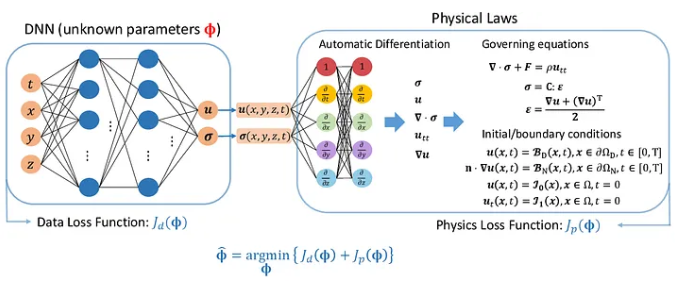


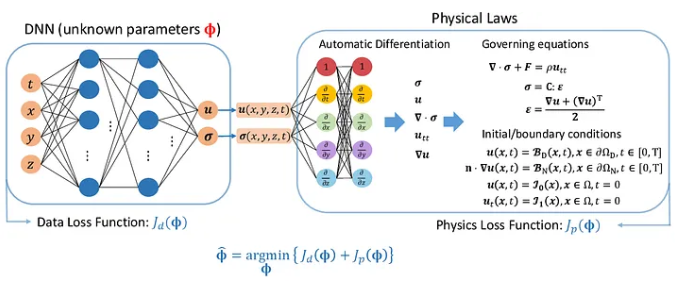
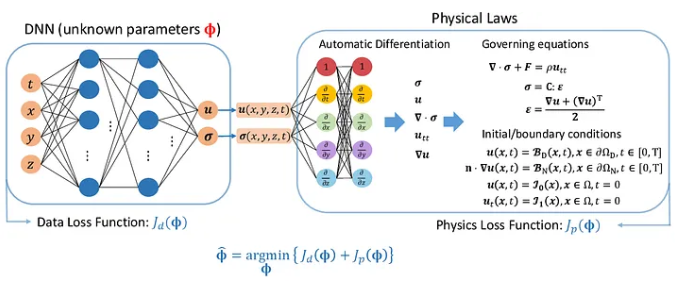

In [1]:
import scipy.io
from scipy.interpolate import griddata
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

## Collect the data

In [2]:
data = scipy.io.loadmat('data/burgers_shock.mat')
x = data['x'].flatten()[:, None]
t = data['t'].flatten()[:, None]
usol = np.real(data['usol']).T
X, T = np.meshgrid(x, t)
train = torch.concat([torch.Tensor(X.flatten()[:, None]), torch.Tensor(T.flatten()[:, None])], dim=1)
X_min = train.min(0)
X_max = train.max(0)

## Make a Neural Network Class

In [3]:
class Network(nn.Module):
    def __init__(self):
        super(Network, self).__init__()
        self.fc1 = nn.Linear(2, 16)
        self.fc2 = nn.Linear(16, 32)
        self.fc3 = nn.Linear(32, 1)

    def forward(self, x):
        x = nn.functional.relu(self.fc1(x))
        x = nn.functional.relu(self.fc2(x))
        x =self.fc3(x)
        return x

## Make a Physics Informed Neural Network Class
- `__init()__`: Initialize the neural network, the optimizer, and other variables used.
- `makeNetwork()`:
    - Concatenate variables in the first layer.
    - Pass through the network.
    - Return the output.
- `residual()`:
    - Residual term acts as a 'regularizer' in the loss.
    - Automatic differentiation: `u_t`, `u_x`, and `u_xx` terms are derived using `torch.autograd.grad`.
- `train():` Train the neural network
    - The `physics` parameter specifies whether to use a PINN or vanilla neural network
    - The `loss` term contains both loss terms where:
        - `u_pred` corresponds to $u_\theta$
        - `residual_pred` corresponds to $f$ (❓double check❓)
    - Perform backpropagation as a last step.
- `predict():` Evaluate the network.

In [4]:
class PINN():
    def __init__(self, X, u, lb, ub, physics):

        self.lb = torch.tensor(lb).float()
        self.ub = torch.tensor(ub).float()
        self.physics = physics

        self.x = torch.tensor(X[:, 0:1], requires_grad=True).float()
        self.t = torch.tensor(X[:, 1:2], requires_grad=True).float()
        self.u = torch.tensor(u).float()

        self.network = Network()

        self.optimizer = torch.optim.Adam(self.network.parameters(), lr=0.001)

    def makeNetwork(self, x, t):
        X = torch.cat([x, t], 1)
        return self.network(X)

    def residual(self, x, t):
        u = self.makeNetwork(x, t)
        u_t = torch.autograd.grad(u, t, grad_outputs=torch.ones_like(u), create_graph=True)[0]
        u_x = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0]
        u_xx = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]
        return u_t + u*u_x - (0.01/np.pi)*u_xx

    def train(self, epochs):
        lossTracker = []
        self.network.train()
        for idx in range(epochs):
            u_pred = self.makeNetwork(self.x, self.t)
            residual_pred = self.residual(self.x, self.t)
            loss = torch.mean((self.u - u_pred)**2)
            if self.physics == True:
                loss += torch.mean(residual_pred**2)
            #print(f"The loss at epoch {idx} is {loss.item()}")
            lossTracker.append(loss.item())
            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()
        return lossTracker

    def predict(self):
        self.network.eval()
        u = self.makeNetwork(self.x, self.t)
        res = self.residual(self.x, self.t)
        return u.detach().numpy(), res.detach().numpy()

## Train the PINN

In [5]:
idx = np.random.choice(train.shape[0], 2000, replace=False)
X_u_train = train[idx, :]
u_train = usol.flatten()[:, None][idx,:]
model = PINN(X_u_train, u_train, X_min[0], X_max[0], True)  # Keep False for Vanilla NN
pinn = model.train(1000)

C:\Users\sofia\AppData\Local\Temp\ipykernel_21532\3318740424.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.lb = torch.tensor(lb).float()
C:\Users\sofia\AppData\Local\Temp\ipykernel_21532\3318740424.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.ub = torch.tensor(ub).float()
C:\Users\sofia\AppData\Local\Temp\ipykernel_21532\3318740424.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.x = torch.tensor(X[:, 0:1], requires_grad=True).float()
C:\Users\sofia\AppData\Local\Temp\ipykernel_21532\3318740424.py:9: UserWar

## Print the Training Curve

In [6]:
import plotly.graph_objects as go

epochs = list(range(len(pinn)))
fig = go.Figure()
fig.add_trace(go.Scatter(x=epochs, y=pinn, mode='lines', name='PINN'))
fig.update_layout(
    title='Loss vs. Epochs',
    xaxis=dict(title='Epochs'),
    yaxis=dict(title='Loss'),
    legend=dict(x=0.7, y=1.0),
    margin=dict(l=20, r=20, t=40, b=20),
    hovermode='x unified'
)
fig.show()